## Проект Тюрин
### Построение модели SARIMA и визуализация данных

Для начала импортируем библиотеки и загрузим датасет, состоящий из данных акций компании SBER каждый день, начиная с 1999 года 

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
import datetime

In [198]:
df = pd.read_csv('PLZL_python_ready_with_close.csv',parse_dates = ['datetime'], index_col = 'datetime')
#https://github.com/MovetOn31/SomeProjects/blob/main/SBER_D1.csv

In [199]:
df.tail()

,open,high,low,close,price,volume,change_pct
datetime,,,,,,,
2024-12-25,13735.0,13990.0,13605.5,13973.5,13973.5,129460.0,0.0186
2024-12-26,13975.0,14138.0,13870.0,14001.0,14001.0,127160.0,0.0020
2024-12-27,14001.0,14140.0,13982.5,14139.0,14139.0,92410.0,0.0099
2024-12-28,14140.0,14140.0,13840.0,13926.0,13926.0,112050.0,-0.0151
2024-12-30,13989.0,14044.5,13927.0,13981.0,13981.0,63180.0,0.0039


In [200]:
df.describe()

,open,high,low,close,price,volume,change_pct
count,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3.001000e+03,3003.000000
mean,6879.082784,6974.695837,6769.894572,6877.450350,6877.450350,9.607792e+04,0.001161
std,4919.391235,4985.701537,4839.388009,4915.209616,4915.209616,1.350569e+05,0.022427
min,459.000000,463.000000,454.000000,459.000000,459.000000,5.000000e+01,-0.246200
25%,3030.000000,3100.000000,2930.000000,3025.000000,3025.000000,9.030000e+03,-0.008500
50%,4987.000000,5044.500000,4924.500000,4990.000000,4990.000000,5.192000e+04,-0.000100
75%,11479.000000,11654.500000,11310.000000,11472.500000,11472.500000,1.369500e+05,0.009600
max,18440.000000,18773.000000,18077.500000,18592.000000,18592.000000,3.010000e+06,0.183200


Итак, сторить модель мы будем для столбца close – цена закрытия дня.

In [201]:
y = df['open'].copy()

Посмотрим как выглядит график для анализа, надо ли приводить ряд к стационарному

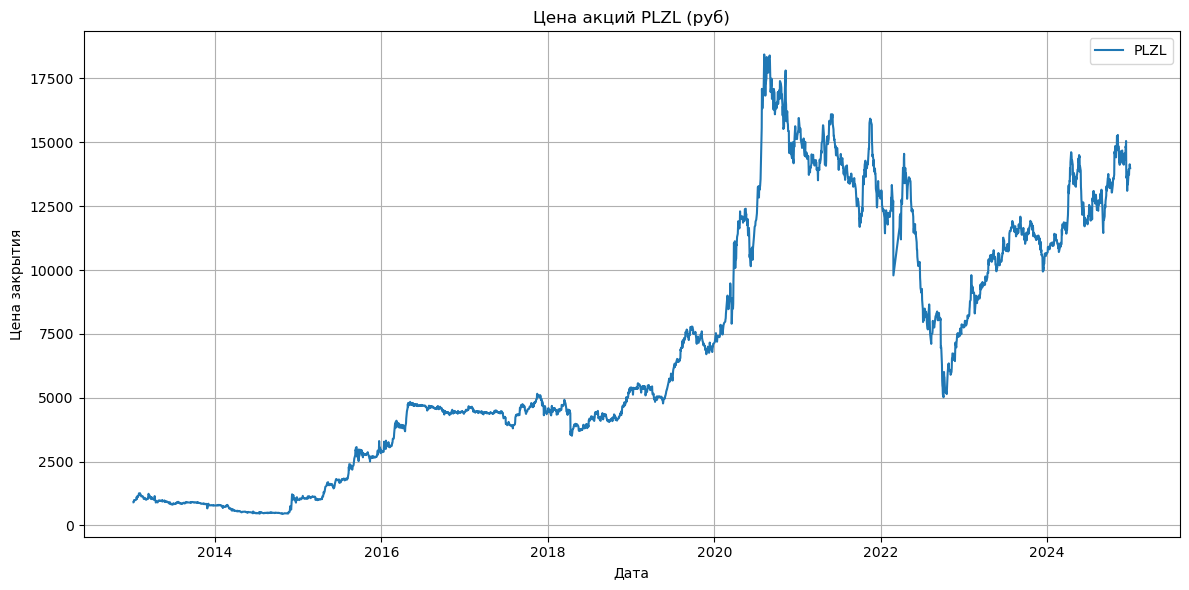

In [202]:
plt.figure(figsize = (12, 6))
plt.plot(y, label = 'PLZL')
plt.title('Цена акций PLZL (руб)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Из графика видно, что мы имеем тренд, сезонность тоже очевидно есть, но сказать сразу какая она, не понятно

Для проверки на стационарность воспользуемся тестом Дики-Фуллера из statsmodels

In [203]:
from statsmodels.tsa.stattools import adfuller
adfuller (y, regression = 'ct', autolag = 'AIC')

(-2.518559381680605,
 0.31874624423603803,
 24,
 2978,
 {'1%': -3.961813203872126,
  '5%': -3.4119652986459013,
  '10%': -3.1279186771397582},
 39458.96172121641)

Как мы видим p-value около 5%, значит мы не можем строго сказать, что ряд стационарен, значет нам его надо преобразовать

Сделаем в таком случае дифференциирование (1 раз), если не пройдет, то второй раз, далее не имеет значения

In [204]:
df['diff1'] = df['open'].diff()
df_diff1 = df['diff1'].dropna()

#Проверка ADF - теста
adfuller(df_diff1, regression = 'n', autolag = 'AIC')

(-9.51674264563788,
 1.1790207126885469e-16,
 23,
 2978,
 {'1%': -2.566491181306749,
  '5%': -1.9410905730128676,
  '10%': -1.6167311176930435},
 39448.170189487406)

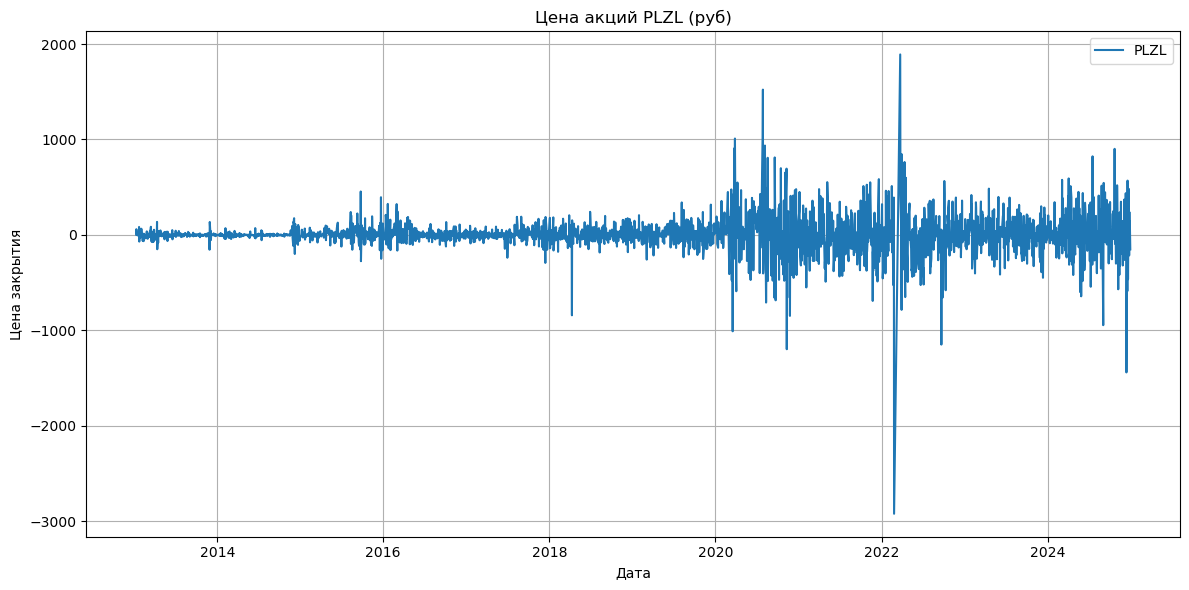

In [205]:
plt.figure(figsize = (12, 6))
plt.plot(df_diff1, label = 'PLZL')
plt.title('Цена акций PLZL (руб)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Отлично, теперь p-palue стремится к нулю, то есть ряд стал стационарным и мы сможем с этим работать. Сейчас разобьем ряд на train и test

In [206]:
# Выбран такой параметр, чтобы мы предсказали 31 позицию
split_ratio = 0.990 #0.996
split_index = int(len(y) * split_ratio)
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index :]
y_train.tail()

datetime
2024-11-12    14208.5
2024-11-13    14445.0
2024-11-14    14120.0
2024-11-15    14173.5
2024-11-18    14302.0
Name: open, dtype: float64

Для начала напишем функции обычного дифференциирование и сезонное 

In [207]:
def difference (data, order = 1, seasonal_order = 0, seasonal_period = 1):
    """
    Функция вычисления дифференциала для ряда (как сезонное так и обычное)
    :param data: series -> series – произвольный дифференциируемый ряд
    :param order: int -> int – количество дифференциирования (обычно 0 - 2)
    :param seasonal_order: int -> int – количество дифференциирования (обычно 0 – 2)
    :param seasonal_period: int -> int – период сезонности для дифференциирования
    :return: другой ряд, который уже продифференциирован
    """
    
    diff = data.copy()
    for _ in range(order):
        diff = diff.diff().dropna()
    for _ in range(seasonal_order):
        diff = diff.diff(seasonal_period).dropna()
    return diff

Теперь создадим функцию лагов для AR(авторегрессии) части 

In [208]:
def create_lags(data, lags):
    """
    Функция создания лагов для AR части
    :param data: series -> series – ряд, с которым работаем
    :param lags: array -> array – массив из лагов
    :return: другой ряд, который состоит из лагов
    """
    df = pd.concat([data.shift(i) for i in lags], axis = 1)
    df.columns = [f'lag_{i}' for i in lags]
    return df

Введу сезонный период и лаги

In [209]:
seasonal_period = 14
y_train_diff = difference(y_train, order = 1, seasonal_order = 1, seasonal_period = seasonal_period)
ar_lags = [1, 2, 3, 14]
X_ar = create_lags(y_train_diff, ar_lags).dropna()
y_ar = y_train_diff[X_ar.index]

### Теперь мы можем добавить Линейную регрессиию и обучить на ряде

In [210]:
ar_model = LinearRegression().fit(X_ar, y_ar)
residuals = y_ar - ar_model.predict(X_ar)  #Получим остаток от AR модели 

Теперь добавим часть скользящего среднего (MA(q))

Создам лаги ошибок

In [211]:
def create_error_lags(residuals, ma_lags):
    """
    Функция создания лагов для MA части
    :param residuals: series -> series – ряд из ошибок AR части
    :param lags: array -> array – массив из лагов
    :return: другой ряд, который состоит из лагов
    """
    X_ma = pd.concat([residuals.shift(i) for i in ma_lags], axis = 1).dropna()
    return X_ma

Добавляю тестовые лаги для MA части

In [212]:
ma_lags = [1, 2, 3]
X_ma = create_error_lags(residuals, ma_lags)
y_ma = y_ar[X_ma.index]

И еще обучим линейную регрессию по ошибкам 

In [213]:
ma_model = LinearRegression().fit(X_ma, y_ma)

Попробуем спрогнозировать с учетом AR и MA

In [214]:
def forecast_next_day(y_series, y_diff_series, residuals, ar_model, ma_model, ar_lags, ma_lags, s = 14):
    """
    :param  y_series: series  -> series - временной ряд
    :param  y_diff_series: series -> series - продифференциированный ряд 
    :param  residuals: series -> series - массив ошибок AR части
    :param  ar_model: LinearRegression -> LinearRegression - Обученная модель MA
    :param  ma_model: LinearRegression -> LinearRegression - Обученная модель MA
    :param  ar_lags: array -> array - массив лагов AR
    :param  ma_lags: array -> array - массив лагов MA
    :param  s: int -> int - сезонность
    :return: tuple (2, float)
    """
    #Сначала AR часть 
    ar_vals = [y_diff_series.iloc[-i] for i in ar_lags]
    X_ar_pred = pd.DataFrame([ar_vals], columns = X_ar.columns)
    ar_pred = ar_model.predict(X_ar_pred)[0]

    #MA часть 
    ma_vals = [residuals.iloc[-i] if len(residuals) >= i else 0 for i in ma_lags]
    X_ma_pred = pd.DataFrame([ma_vals], columns = X_ma.columns)
    ma_pred = ma_model.predict(X_ma_pred)[0]

    #Комбнируем данные прогнозы и центрируем результаты
    diff_forecast = ar_pred + (ma_pred - np.mean(y_ma))

    #Сразу восстановим значения
    y_last = y_series.iloc[-1]
    y_seasonal = y_series.iloc[- s]
    y_seasonal_prev = y_series.iloc[-s-1]
    level_forecast = diff_forecast + y_last + y_seasonal - y_seasonal_prev
    return (level_forecast, diff_forecast)


Получим прогноз на следующий день 

In [215]:
forecast_combined = forecast_next_day(y_train, y_train_diff, residuals, ar_model, ma_model, ar_lags, ma_lags, s = 14)
print('Прогноз с SARIMA: ', forecast_combined)

Прогноз с SARIMA:  (14245.368604188778, -265.13139581122107)


Осталось добавить разбивку на тест и обучение, прогноз на n шагов впереж веперед, визуализация и проверка на MAE или RMSE тесты 

Пропишем значения для проверки нашего алгоритма 

In [216]:
n_steps = len(y_test)

А сейчас реализую алгоритм для предсказывания на n_steps дней вперед

In [217]:
def forecast_for_n_days(y_temp, y_diff_temp, resid_temp, ar_model, ma_model, ar_lags, ma_lags, s = 14, n_steps = 1):
    """
    :param  y_temp: series  -> series - временной ряд
    :param  y_diff_temp: series -> series - продифференциированный ряд 
    :param  resid_temp: series -> series - массив ошибок AR части
    :param  ar_model: LinearRegression -> LinearRegression - Обученная модель MA
    :param  ma_model: LinearRegression -> LinearRegression - Обученная модель MA
    :param  ar_lags: array -> array - массив лагов AR
    :param  ma_lags: array -> array - массив лагов MA
    :param  s: int -> int - сезонность
    :param  n_steps: int -> int - количество прогнозируемых шагов
    :return: tuple (2, float)
    """
    forecast_values = []
    forecast_diff = []
    for _ in range (n_steps):
        level_forecast, diff_f = forecast_next_day(y_temp, y_diff_temp, resid_temp, ar_model, ma_model, ar_lags, ma_lags)
        forecast_values.append(level_forecast)
        forecast_diff.append(diff_f)

        new_index = y_temp.index[-1] + pd.Timedelta(days = 1)
    
        y_temp = pd.concat([y_temp, pd.Series([level_forecast], index = [new_index])])

        new_diff = level_forecast - y_temp.iloc[-2] - (y_temp.iloc[-s-1] - y_temp.iloc[-s-2])
        y_diff_temp = pd.concat([y_diff_temp, pd.Series([new_diff], index = [new_index])])
    
        ar_vals = [y_diff_temp.iloc[-i] for i in ar_lags]
        X_ar_pred = pd.DataFrame([ar_vals], columns=X_ar.columns)
        ma_vals = [resid_temp.iloc[-i] if len(resid_temp) >= i else 0 for i in ma_lags]
        X_ma_pred = pd.DataFrame([ma_vals], columns=X_ma.columns)
        new_resid = new_diff - (ar_model.predict(X_ar_pred)[0] + ma_model.predict(X_ma_pred)[0] - np.mean(y_ma))
        resid_temp = pd.concat([resid_temp, pd.Series([new_resid], index=[new_index])])

    forecast_index = y_test.index
    forecast_series = pd.Series(forecast_values[:len(forecast_index)], index = forecast_index)

    return forecast_series, forecast_index

Итак, заберем данные после цикла

In [243]:
forecast_series, forecast_index = forecast_for_n_days(y_train, y_train_diff, residuals, ar_model, ma_model, ar_lags, ma_lags, s = 252, n_steps = n_steps,)

Давайте посмотрим что нам выдала SARIMA и сравним с истинными значениями 


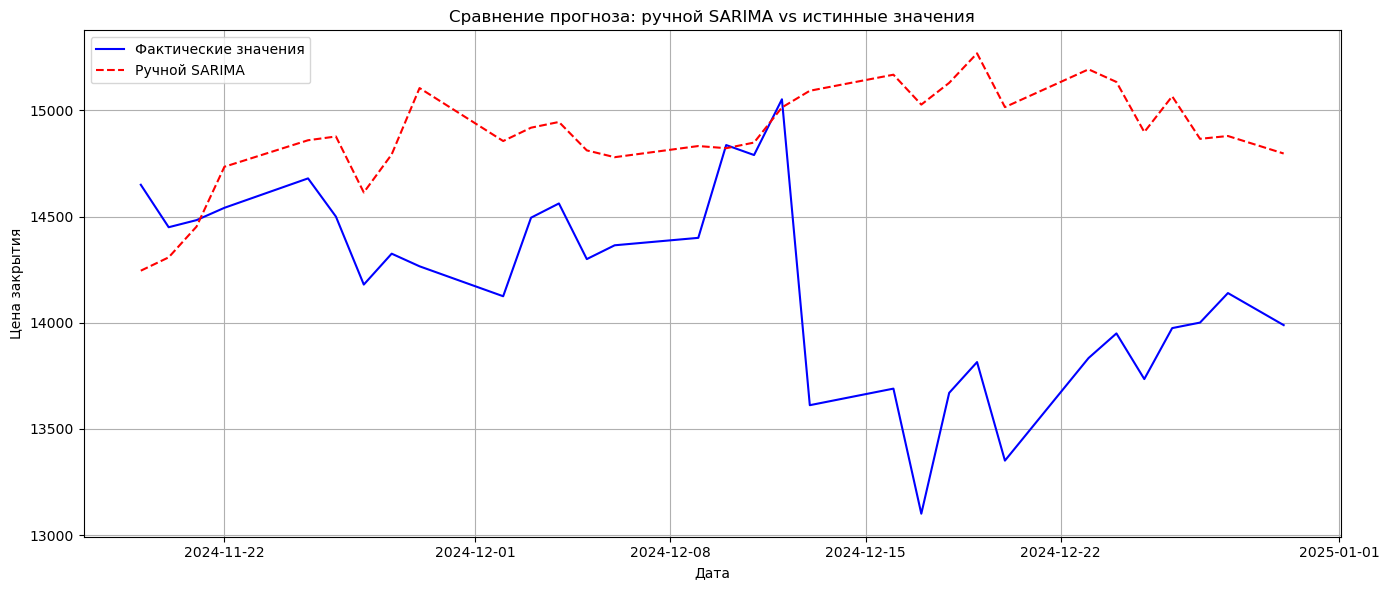

In [244]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Фактические значения', color='blue')
plt.plot(y_test.index, forecast_series.values, label='Ручной SARIMA', linestyle='--', color='red')
plt.title('Сравнение прогноза: ручной SARIMA vs истинные значения')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Добавлю проверку при поощи известных метрик – MAE(Средняя абсолютная ошибка) и MSE(Средняя квадратичная ошибка под корнем)

In [245]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_SARIMA = mean_absolute_error(y_test, forecast_series)
mse_SARIMA = mean_squared_error(y_test, forecast_series)

print (f'Средня абсолютная ошибка {mae_SARIMA}')
print (f'Средня квадратичная ошибка {mse_SARIMA}')

Средня абсолютная ошибка 733.9380185615782
Средня квадратичная ошибка 833662.3098687145


Можно сделать вывод, что модель справляется не плохо, так как процент средней ошибки относительно цены акции около 5%

Теперь функция для вывода графика в виде candle

In [221]:
def draw_candlestick(df, timeframe, theme="TV Mode", limit_to_day=None, # функция построения свечного графика
                     mark_global_max=None, mark_global_min=None,
                     mark_local_max=None, mark_local_min=None,
                     ):
  stock_prices = df.copy() #сохраняем исходные данные
  if limit_to_day: # фильтрация по нужному отрезку
    # limit_to_day = "01-12-2022 9:00:00"
    stock_prices = stock_prices[stock_prices['datetime']>datetime.datetime.strptime(limit_to_day, '%d-%m-%Y %H:%M:%S')]
  # print(stock_prices), для проверки данных после фильтрации

  df = stock_prices # ссылаемся на отфильтрованные данные

  # удаление нерабочих часов из данных
  dt_breaks = []
  if timeframe=="H1":
    # взятие первого и последнего наблюдения из df.date и создание непрерывного диапазона дат на их основе
    dt_all = pd.date_range(start=df['datetime'].iloc[0],end=df['datetime'].iloc[-1], freq = '1H')
    # проверка, какие даты из нашего источника также соответствуют непрерывному диапазону дат
    dt_obs = [d.strftime("%Y-%m-%d %H:%M:%S") for d in df['datetime']]
    # изолирование недостающих временных меток
    dt_breaks = [d for d in dt_all.strftime("%Y-%m-%d %H:%M:%S").tolist() if not d in dt_obs]
    dt_breaks = pd.to_datetime(dt_breaks)
    
  tv_dark = {}
  tv_dark["bg_color"] = "#171b26" # цвет фона области графика
  tv_dark["plot_bg_color"] = "#171b26"  # цвет фона внутри графика
  tv_dark["grid_color"] = "#222631"  # цвет сетки
  tv_dark["text_color"] = "#a7abb6"  # цвет текста (подписи осей, легенда)
  tv_dark["dark_candle"] = "#f23644"  # цвет медвежьей (падающей) свечи
  tv_dark["light_candle"] = "#079a80"  # цвет бычьей (растущей) свечи
  tv_dark["volume_color"] = "#5c285b"  # цвет объёмов (если будут добавлены)
  tv_dark["border_color"] = "#ffffff"  # цвет границ
  tv_dark["color_1"] = "#5c285b" # доп. цвета (для линий, маркеров и т.д.)
  tv_dark["color_2"] = "#802c62"
  tv_dark["color_3"] = "#a33262"
  tv_dark["color_4"] = "#c43d5c"
  tv_dark["color_5"] = "#de4f51"
  tv_dark["color_6"] = "#f26841"
  tv_dark["color_7"] = "#fd862b"
  tv_dark["color_8"] = "#ffa600"
  tv_dark["color_9"] = "#3366d6"   
  dark_palette = {} # альтернативная тёмная цветовая палитра
  dark_palette["bg_color"] = "#2e2e2e"  # цвет фона всей области графика
  dark_palette["plot_bg_color"] = "#2e2e2e"  # цвет фона внутри графика (где свечи)
  dark_palette["grid_color"] = "#595656"  # цвет сетки
  dark_palette["text_color"] = "#ffffff"  # цвет текста (подписи осей, легенды)
  dark_palette["dark_candle"] = "#226287"  # цвет падающих свечей
  dark_palette["light_candle"] = "#a6a4a4"  # цвет растущих свечей
  dark_palette["volume_color"] = "#5c285b"  # цвет объёмов (если будут добавлены)
  dark_palette["border_color"] = "#ffffff"  # цвет границ 
  dark_palette["color_1"] = "#5c285b"  # доп. цвета (для линий, маркеров и т.д.)
  dark_palette["color_2"] = "#802c62"
  dark_palette["color_3"] = "#a33262"
  dark_palette["color_4"] = "#c43d5c"
  dark_palette["color_5"] = "#de4f51"
  dark_palette["color_6"] = "#f26841"
  dark_palette["color_7"] = "#fd862b"
  dark_palette["color_8"] = "#ffa600"
  dark_palette["color_9"] = "#3366d6"    
  light_palette = {} # альтернативная светлая цветовая палитра
  light_palette["bg_color"] = "#ffffff"  # цвет фона всей области графика
  light_palette["plot_bg_color"] = "#ffffff"  # цвет фона внутри графика (где свечи)
  light_palette["grid_color"] = "#e6e6e6"  # цвет сетки
  light_palette["text_color"] = "#2e2e2e"  # цвет текста (подписи осей, легенды)
  light_palette["dark_candle"] = "#4d98c4"  # цвет падающих свечей
  light_palette["light_candle"] = "#b1b7ba"  # цвет растущих свечей
  light_palette["volume_color"] = "#c74e96"  # цвет объёмов (если будут добавлены)
  light_palette["border_color"] = "#2e2e2e"  # цвет границ 
  light_palette["color_1"] = "#5c285b"  # доп. цвета (для линий, маркеров и т.д.)
  light_palette["color_2"] = "#802c62"
  light_palette["color_3"] = "#a33262"
  light_palette["color_4"] = "#c43d5c"
  light_palette["color_5"] = "#de4f51"
  light_palette["color_6"] = "#f26841"
  light_palette["color_7"] = "#fd862b"
  light_palette["color_8"] = "#ffa600"
  light_palette["color_9"] = "#3366d6"    

  palette = light_palette
  if theme == "TV Mode": palette = tv_dark
  if theme == "Dark Mode": palette = dark_palette
      
  layout = go.Layout(
      autosize=True, # график автоматически подстраивается под размер контейнера
      # width=1000,
      height=1000, # фиксированная высота графика (1000 пикселей)
      xaxis= go.layout.XAxis(linecolor = 'black', linewidth = 1, mirror = True), # цвет линии оси X, толщина линии и отражение оси на противоположной стороне графика
      yaxis= go.layout.YAxis(linecolor = 'black', linewidth = 1, mirror = True), # то же самое для оси Y
      margin=go.layout.Margin(l=50, r=50, b=100, t=100, pad = 4 ), # добавление осей с обратной стороны графика и настройка отступов
      font=dict(family="Verdana", size=12, color=palette["text_color"]), # шрифт
      plot_bgcolor=palette["plot_bg_color"],  # цвет фона области графика (где свечи)
      paper_bgcolor=palette["bg_color"],  # цвет фона вокруг графика
      
  )

  fig = go.Figure(data=[go.Candlestick(x=df['datetime'], # создание фигуры, временная ось X
                  open=df['open'],  # цена открытия
                  high=df['high'],  # максимальная цена
                  low=df['low'],  # минимальная цена
                  close=df['close'],  # цена закрытия
                  increasing_line_color=palette['light_candle'], decreasing_line_color=palette['dark_candle'], # цвета растущей и падающей свечей и толщина их линий
                  increasing_line_width=1, decreasing_line_width=1,
                  ),], layout=layout)
  
  if mark_global_max:  # проверка наличия глобального максимума
    x = mark_global_max['x']
    y = mark_global_max['y']
    fig.add_trace(go.Scatter(x=x, y=y, name='max', mode='markers', marker=dict(
            size=16,
            color='rgba(0, 0, 255, .8)',
            line_width=1,
        )))    
  if mark_local_max:  # проверка наличия локального максимума
    x = mark_local_max['x']
    y = mark_local_max['y']
    fig.add_trace(go.Scatter(x=x, y=y, name='_max', mode='markers', marker=dict(
            size=12,
            color='rgba(0, 0, 128, .8)',
            line_width=1,
      )))

  if mark_global_min: # проверка наличия глобального минимума
    x = mark_global_min['x']  # список времён
    y = mark_global_min['y']  # список цен
    fig.add_trace(go.Scatter(x=x, y=y, name='min', mode='markers', marker=dict(
            size=16,
            color='rgba(255, 0, 0, .8)',
            line_width=1,
        )))
  if mark_local_min: # проверка наличия локального минимума
    x = mark_local_min['x']
    y = mark_local_min['y']
    fig.add_trace(go.Scatter(x=x, y=y, name='_min', mode='markers', marker=dict(
            size=12,
            color='rgba(128, 0, 0, .8)',
            line_width=1,
        )))

  fig.update_layout(xaxis_rangeslider_visible=False) # отключение ползунка времени(экономит место)
  fig.update_xaxes(rangebreaks=[dict(dvalue = 60*60*1000, values=dt_breaks)] )  # скрытие пропущенных периодов

  #  настройка сетки
  fig.update_xaxes(showline=True, linewidth=1, linecolor=palette["grid_color"],gridcolor=palette["grid_color"])
  fig.update_yaxes(showline=True, linewidth=1, linecolor=palette["grid_color"],gridcolor=palette["grid_color"])

  fig.show()  # отображение графика

In [222]:
tf = "D1"
df = pd.read_csv('PLZL_python_ready_with_close.csv', parse_dates=['datetime'])
df = df[len(df)-800:]

In [223]:
mark_global_max, x, y = None, [], []
# mark_global_max = {'x': x, 'y': y}
mark_local_min, x, y = None, [], []
# mark_local_min = {'x': x, 'y': y}

draw_candlestick(df=df, timeframe=tf, theme="TV Mode", limit_to_day=None, mark_global_max=mark_global_max, mark_local_min=mark_local_min)